In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df=pd.read_csv("/workspaces/Aress_Task/data/Churn_preprocssing.csv")

In [62]:
df.head()

,CustomerId,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,15634602,619,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,15647311,608,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,15619304,502,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,15701354,699,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,15737888,850,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0


In [63]:
df=df.drop(['CustomerId'],axis=1)

In [64]:
df.shape

(10000, 13)

In [65]:
X=df.drop(['Exited'],axis=1)
y=df['Exited']

In [66]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split( X,y,test_size=0.2,random_state=42)

In [67]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

In [69]:
print(type(X_train))
print(X_train)

<class 'numpy.ndarray'>
[[ 0.35649971  0.91324755 -0.6557859  ...  1.00150113 -0.57946723
  -0.57638802]
 [-0.20389777  0.91324755  0.29493847 ... -0.99850112  1.72572313
  -0.57638802]
 [-0.96147213  0.91324755 -1.41636539 ... -0.99850112 -0.57946723
   1.73494238]
 ...
 [ 0.86500853 -1.09499335 -0.08535128 ...  1.00150113 -0.57946723
  -0.57638802]
 [ 0.15932282  0.91324755  0.3900109  ...  1.00150113 -0.57946723
  -0.57638802]
 [ 0.47065475  0.91324755  1.15059039 ... -0.99850112  1.72572313
  -0.57638802]]


In [70]:
## convert dataram to tensor
X_train=torch.tensor(X_train,dtype=torch.float32)
X_test=torch.tensor(X_test,dtype=torch.float32)
y_train = torch.tensor(np.array(y_train), dtype=torch.long)
y_test  = torch.tensor(np.array(y_test), dtype=torch.long)


In [71]:
print(type(y_train))
print(y_train)

<class 'torch.Tensor'>
tensor([0, 0, 1,  ..., 1, 1, 0])


In [72]:
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # Input → Hidden
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes) # Hidden → Output

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out


In [73]:
X.shape

(10000, 12)

In [80]:
import torch

# Count number of samples per class
class_counts = y_train.bincount()  # works because y_train is long tensor with 0/1
print("Class counts:", class_counts)

# Compute weight for each class: inversely proportional to frequency
class_weights = 1.0 / class_counts.float()
# Normalize weights (optional)
class_weights = class_weights / class_weights.sum() * 2

print("Class weights:", class_weights)

Class counts: tensor([6356, 1644])
Class weights: tensor([0.4110, 1.5890])


In [81]:

input_size = X_train.shape[1]  
hidden_size = 8
num_classes = len(set(y))
model = SimpleNN(input_size, hidden_size, num_classes)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=0.01)



In [82]:
train_losses = []
val_losses = []

epochs = 100
patience = 2
best_val_loss = float('inf')
counter = 0

for epoch in range(epochs):

    # ===== TRAINING =====
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # ===== VALIDATION =====
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test)
        val_loss = criterion(val_outputs, y_test)
        val_losses.append(val_loss.item())

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {loss.item():.4f} "
          f"Val Loss: {val_loss.item():.4f}")

    # ===== EARLY STOPPING LOGIC =====
    if val_loss.item() < best_val_loss:
        best_val_loss = val_loss.item()
        counter = 0
        best_model_state = model.state_dict()  # save best weights
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered!")
        break

# Load best model weights
model.load_state_dict(best_model_state)

Epoch [1/100] Train Loss: 0.7029 Val Loss: 0.6920
Epoch [2/100] Train Loss: 0.6930 Val Loss: 0.6839
Epoch [3/100] Train Loss: 0.6845 Val Loss: 0.6767
Epoch [4/100] Train Loss: 0.6768 Val Loss: 0.6698
Epoch [5/100] Train Loss: 0.6696 Val Loss: 0.6633
Epoch [6/100] Train Loss: 0.6627 Val Loss: 0.6567
Epoch [7/100] Train Loss: 0.6560 Val Loss: 0.6501
Epoch [8/100] Train Loss: 0.6494 Val Loss: 0.6434
Epoch [9/100] Train Loss: 0.6429 Val Loss: 0.6368
Epoch [10/100] Train Loss: 0.6365 Val Loss: 0.6303
Epoch [11/100] Train Loss: 0.6303 Val Loss: 0.6242
Epoch [12/100] Train Loss: 0.6246 Val Loss: 0.6187
Epoch [13/100] Train Loss: 0.6194 Val Loss: 0.6137
Epoch [14/100] Train Loss: 0.6150 Val Loss: 0.6095
Epoch [15/100] Train Loss: 0.6112 Val Loss: 0.6060
Epoch [16/100] Train Loss: 0.6080 Val Loss: 0.6030
Epoch [17/100] Train Loss: 0.6055 Val Loss: 0.6005
Epoch [18/100] Train Loss: 0.6033 Val Loss: 0.5980
Epoch [19/100] Train Loss: 0.6011 Val Loss: 0.5956
Epoch [20/100] Train Loss: 0.5990 Val Lo

<All keys matched successfully>

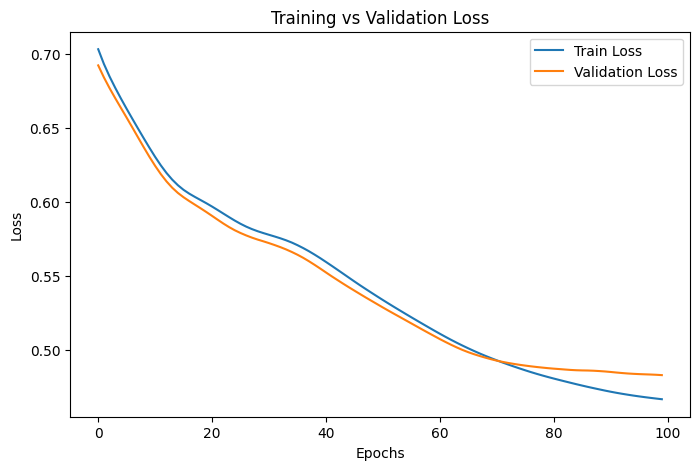

In [83]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.show()

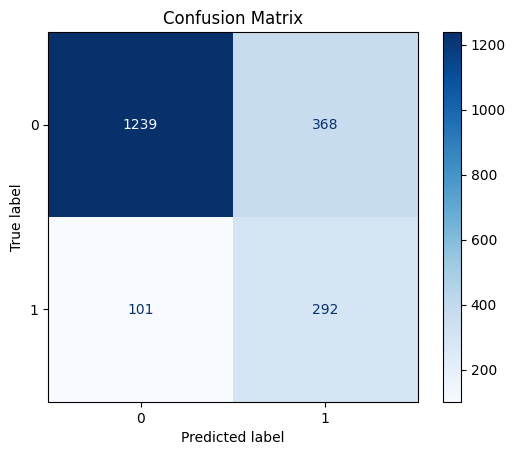

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)

cm = confusion_matrix(y_test.cpu(), predicted.cpu())

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [85]:
with torch.no_grad():
    outputs = model(X_test)
    _, predicted = torch.max(outputs, 1)
    accuracy = (predicted == y_test).sum().item() / y_test.size(0)
    print(f"Test Accuracy: {accuracy*100:.2f}%")

Test Accuracy: 76.55%


In [86]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_test.cpu(), predicted.cpu()))

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.77      0.84      1607
           1       0.44      0.74      0.55       393

    accuracy                           0.77      2000
   macro avg       0.68      0.76      0.70      2000
weighted avg       0.83      0.77      0.78      2000



In [89]:
torch.save(model.state_dict(), "churn_model_weights.pth")

In [90]:
# Recreate the same architecture
model = SimpleNN(input_size, hidden_size, num_classes)

# Load weights
model.load_state_dict(torch.load("churn_model_weights.pth"))

# Set to eval mode
model.eval()

SimpleNN(
  (fc1): Linear(in_features=12, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=2, bias=True)
)